Name: Amresh Kumar Yadav
Student ID: 2418108

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Introduction to Python Imaging Library(PIL)

**Exercise - 1**

In [26]:
# Import libraries
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

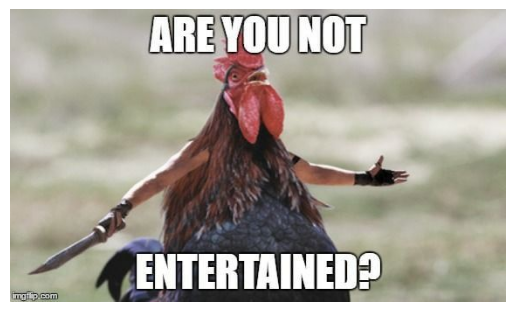

In [27]:
# 1. Read and display the image.

# Open the image
img = Image.open("/content/drive/MyDrive/AI & ML/Week 01/test.jpg")

# Display the image using matplotlib
plt.imshow(img)
plt.axis('off')  # Hide axis
plt.show()

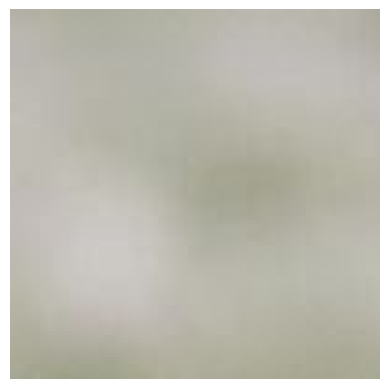

In [28]:
# 2. Display only the top left corner of 100x100 pixels.

# Convert image to NumPy array
img_array = np.array(img)

# Extract top-left 100x100 pixels using array indexing
top_left = img_array[0:100, 0:100]

# Display the extracted part
plt.imshow(top_left)
plt.axis('off')
plt.show()

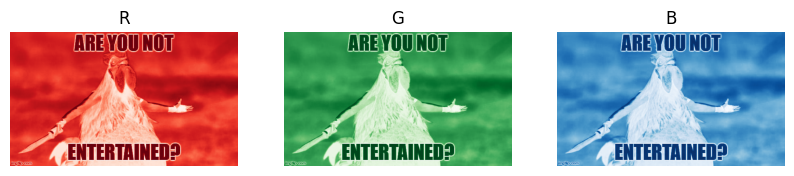

In [29]:
# 3. Show the three color channels (R, G, B).
# Separate channels using NumPy
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display channels
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("R")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("G")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("B")
plt.axis("off")

plt.show()

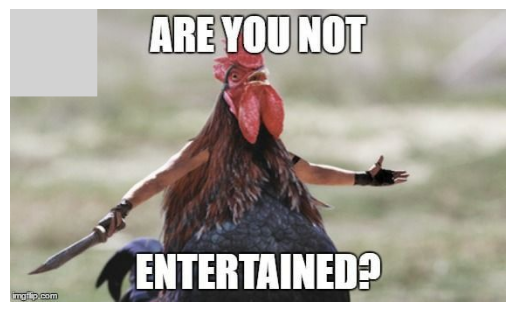

In [30]:
# 4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
img_array[0:100, 0:100] = 210

# Display the modified image
plt.imshow(img_array)
plt.axis('off')
plt.show()

**Exercise - 2**

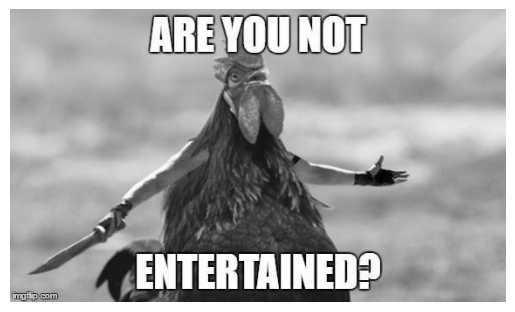

In [31]:
# 1. Load and display a grayscale image.
img = Image.open("/content/drive/MyDrive/AI & ML/Week 01/test.jpg").convert("L")

# Display the grayscale image
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

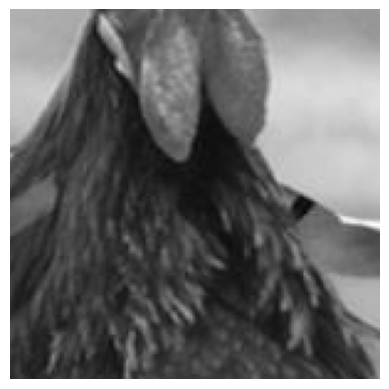

In [32]:
# 2. Extract and display the middle section of the image (150 pixels)
# Convert to NumPy array
img_array = np.array(img)

# Get image dimensions
h, w = img_array.shape

# Find center
center_h = h // 2
center_w = w // 2

# Extract 150x150 region from the center
cropped = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

# Display cropped image
plt.imshow(cropped, cmap='gray')
plt.axis('off')
plt.show()

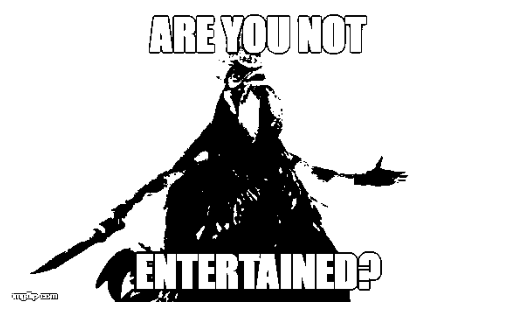

In [33]:
# 3. Apply a simple threshold to the image
# Apply threshold
binary_img = np.where(img_array < 100, 0, 255)

# Display binary image
plt.imshow(binary_img, cmap='gray')
plt.axis('off')
plt.show()

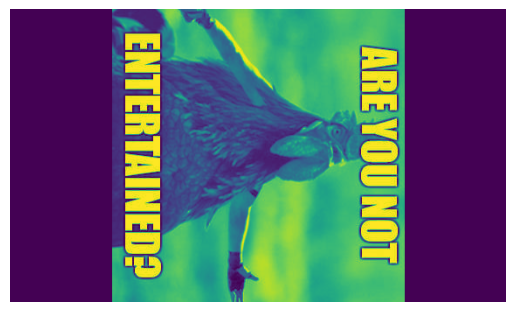

In [34]:
# 4. Rotate the image 90 degrees clockwise and display the result.
# Rotate 90 degrees clockwise
rotated_img = img.rotate(-90)

# Display the rotated image
plt.imshow(rotated_img)
plt.axis('off')
plt.show()

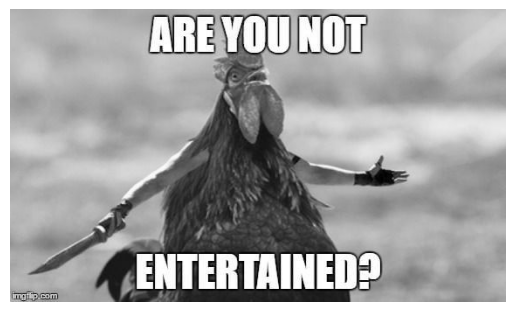

In [35]:
# 5. Convert the grayscale image to an RGB image.
# Convert to NumPy array
gray_array = np.array(img)

# Replicate grayscale values into 3 channels (RGB)
rgb_image = np.stack((gray_array, gray_array, gray_array), axis=-1)

# Display the RGB image
plt.imshow(rgb_image)
plt.axis('off')
plt.show()

**Image Compression and Decompression using PCA**

1. Load and Prepare Data:


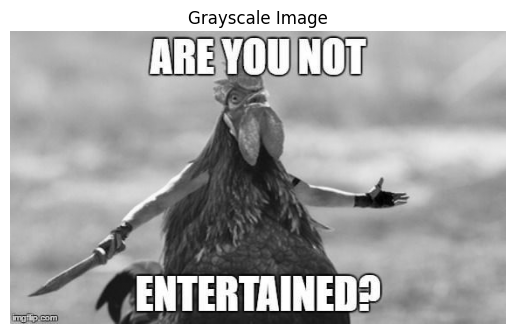

In [36]:
# Load image
img = Image.open("/content/drive/MyDrive/AI & ML/Week 01/test.jpg")

# Convert to grayscale if image is color
img = img.convert("L")

# Convert to NumPy array
img_array = np.array(img)

# Display grayscale image
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

In [37]:
# Center the dataset (Standardize)

# Flatten the image into a 1D dataset
data = img_array.astype(float)

# Calculate mean and standard deviation
mean = np.mean(data, axis=0)
standardized_data = data - mean  # shape: (height, width)

print("Mean after standardization:", np.mean(standardized_data))
print("Std after standardization:", np.std(standardized_data))

Mean after standardization: -2.6766713947490005e-15
Std after standardization: 53.04807766086583


In [38]:
# Covariance Matrix


# Calculate covariance matrix
cov_matrix = np.cov(standardized_data, rowvar=False)

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[135.95576012 129.75440164 132.18951649 ... 151.8290732  146.82344267
  143.53780499]
 [129.75440164 135.46268657 154.97493074 ... 152.17847886 146.82174457
  143.20573778]
 [132.18951649 154.97493074 287.26266869 ... 162.43078023 155.84842256
  151.70010725]
 ...
 [151.8290732  152.17847886 162.43078023 ... 657.38453839 654.05744928
  652.13158459]
 [146.82344267 146.82174457 155.84842256 ... 654.05744928 651.94891411
  650.76252569]
 [143.53780499 143.20573778 151.70010725 ... 652.13158459 650.76252569
  650.27950666]]


2. Eigen Decomposition and Identifying Principal Components:


In [43]:
# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues in descending order and cast to real
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices].real
eigenvectors_sorted = eigenvectors[:, sorted_indices].real

print("Sorted Eigenvalues:", eigenvalues_sorted)
print("Corresponding Eigenvectors shape:", eigenvectors_sorted.shape)

Sorted Eigenvalues: [ 7.11050086e+05  2.41324055e+05  1.23114620e+05  8.02491849e+04
  6.25898972e+04  4.96843861e+04  3.52355415e+04  2.93173318e+04
  2.58963886e+04  2.28792813e+04  2.05003619e+04  1.81839637e+04
  1.67369567e+04  1.44804151e+04  1.26586856e+04  1.13571188e+04
  9.92096620e+03  8.91221786e+03  8.08213334e+03  7.11492384e+03
  5.89790425e+03  5.41537437e+03  5.10053242e+03  4.43729508e+03
  4.30739506e+03  3.92112437e+03  3.78755523e+03  3.37575315e+03
  3.10457092e+03  2.76413842e+03  2.71040633e+03  2.18930513e+03
  2.16486129e+03  2.01625376e+03  1.82835605e+03  1.81240539e+03
  1.65330902e+03  1.61322095e+03  1.50102391e+03  1.48415053e+03
  1.44569442e+03  1.37859196e+03  1.26944756e+03  1.20797167e+03
  1.13684185e+03  1.08855827e+03  1.04172757e+03  9.57079127e+02
  9.17282055e+02  8.85157922e+02  8.46927722e+02  7.87596470e+02
  7.72132901e+02  7.46220669e+02  7.05359158e+02  6.90419746e+02
  6.40735199e+02  6.12855450e+02  5.70044764e+02  5.40456176e+02
  5.2

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


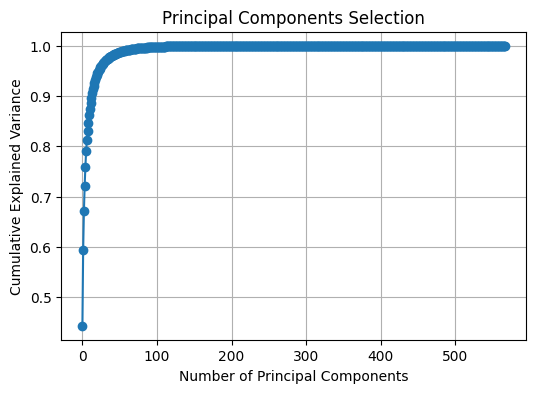

In [40]:
# Cumulative variance plot
cumulative_variance = np.cumsum(eigenvalues_sorted) / np.sum(eigenvalues_sorted)

plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Principal Components Selection')
plt.grid(True)
plt.show()

In [41]:
# Choose top k eigenvectors that explain > 95% variance
k = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of principal components to retain 95% variance: {k}")
top_k_eigenvectors = eigenvectors_sorted[:, :k]

Number of principal components to retain 95% variance: 23


3. Reconstruction and Experiment:

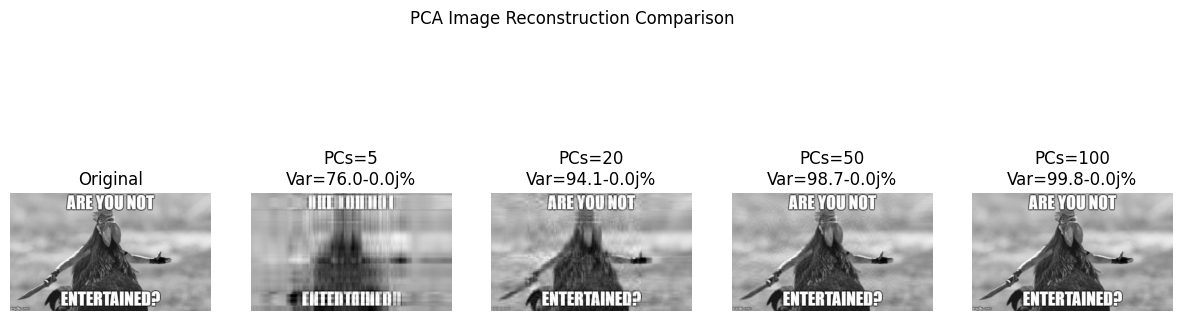

In [44]:
# Function to reconstruct using top k components
def reconstruct_image(data_std, mean, eigenvectors, k):
    top_k_eigvecs = eigenvectors[:, :k]         # select top k eigenvectors
    lower_dim = np.dot(data_std, top_k_eigvecs) # project to lower dimension
    reconstruction = np.dot(lower_dim, top_k_eigvecs.T) + mean
    return reconstruction

# Experiments: Pick 4 different k values
k_values = [5, 20, 50, 100]  # Number of principal components
plt.figure(figsize=(15, 5))

# Display original image
plt.subplot(1, len(k_values)+1, 1)
plt.imshow(img_array, cmap='gray')
plt.title("Original")
plt.axis('off')

# Display reconstructed images
for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(standardized_data, mean, eigenvectors_sorted, k)
    reconstructed = np.clip(reconstructed, 0, 255)

    plt.subplot(1, len(k_values)+1, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"PCs={k}\nVar={cumulative_variance[k-1]*100:.1f}%")
    plt.axis('off')

plt.suptitle("PCA Image Reconstruction Comparison")
plt.show()